# Income classification

# Adult Income Dataset

| Column Name | Description | Values / Type |
|-------------|-------------|---------------|
| age | Age of an individual | Integer > 0 |
| workclass | Employment status of an individual | Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked |
| fnlwgt | Final weight representing the estimated number of people the census entry represents | Integer > 0 |
| education | Highest level of education achieved | Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool |
| education-num | Highest education level in numerical form | Integer > 0 |
| marital-status | Marital status of an individual | Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse |
| occupation | General occupation type | Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces |
| relationship | Relationship to other household members | Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried |
| race | Race of an individual | White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black |
| sex | Biological sex | Male, Female |
| capital-gain | Capital gains | Integer ≥ 0 |
| capital-loss | Capital losses | Integer ≥ 0 |
| hours-per-week | Hours worked per week | Continuous |
| native-country | Country of origin | United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands |
| income (Label) | Annual income class (Target) | <=50K, >50K |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math

warnings.filterwarnings("ignore")
sns.set_style(style= "darkgrid")
plt.rcParams["figure.figsize"] = (16, 8)

In [2]:
df = pd.read_csv("income_evaluation.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
df.isnull().sum()

age                0
 workclass         0
 fnlwgt            0
 education         0
 education-num     0
 marital-status    0
 occupation        0
 relationship      0
 race              0
 sex               0
 capital-gain      0
 capital-loss      0
 hours-per-week    0
 native-country    0
 income            0
dtype: int64

In [7]:
# Fix column name formatting by removing unnecessary leading spaces
for column in df.columns:
    df.rename(
        columns= {
            f"{column}" :f"{column.lstrip()}"
        },
        inplace= True
    )

In [8]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [9]:
def get_categoric(dataFrame = df):
    categoric = dataFrame.select_dtypes(include= "object")
    categoric_columns = categoric.columns

    return categoric_columns

In [10]:
def get_numeric(dataFrame = df):
    numeric = dataFrame.select_dtypes(include= "int")
    numeric_columns = numeric.columns

    return numeric_columns

In [11]:
# Clean categorical values by stripping whitespace and converting to lowercase
categoric = get_categoric()

for column in categoric:
    unique_vals = df[column].unique()
    for val in unique_vals:
        df[column].replace({f"{val}" : f"{val.lstrip().lower()}"}, inplace= True)

## Basic Exploratory Data Analysis(EDA)

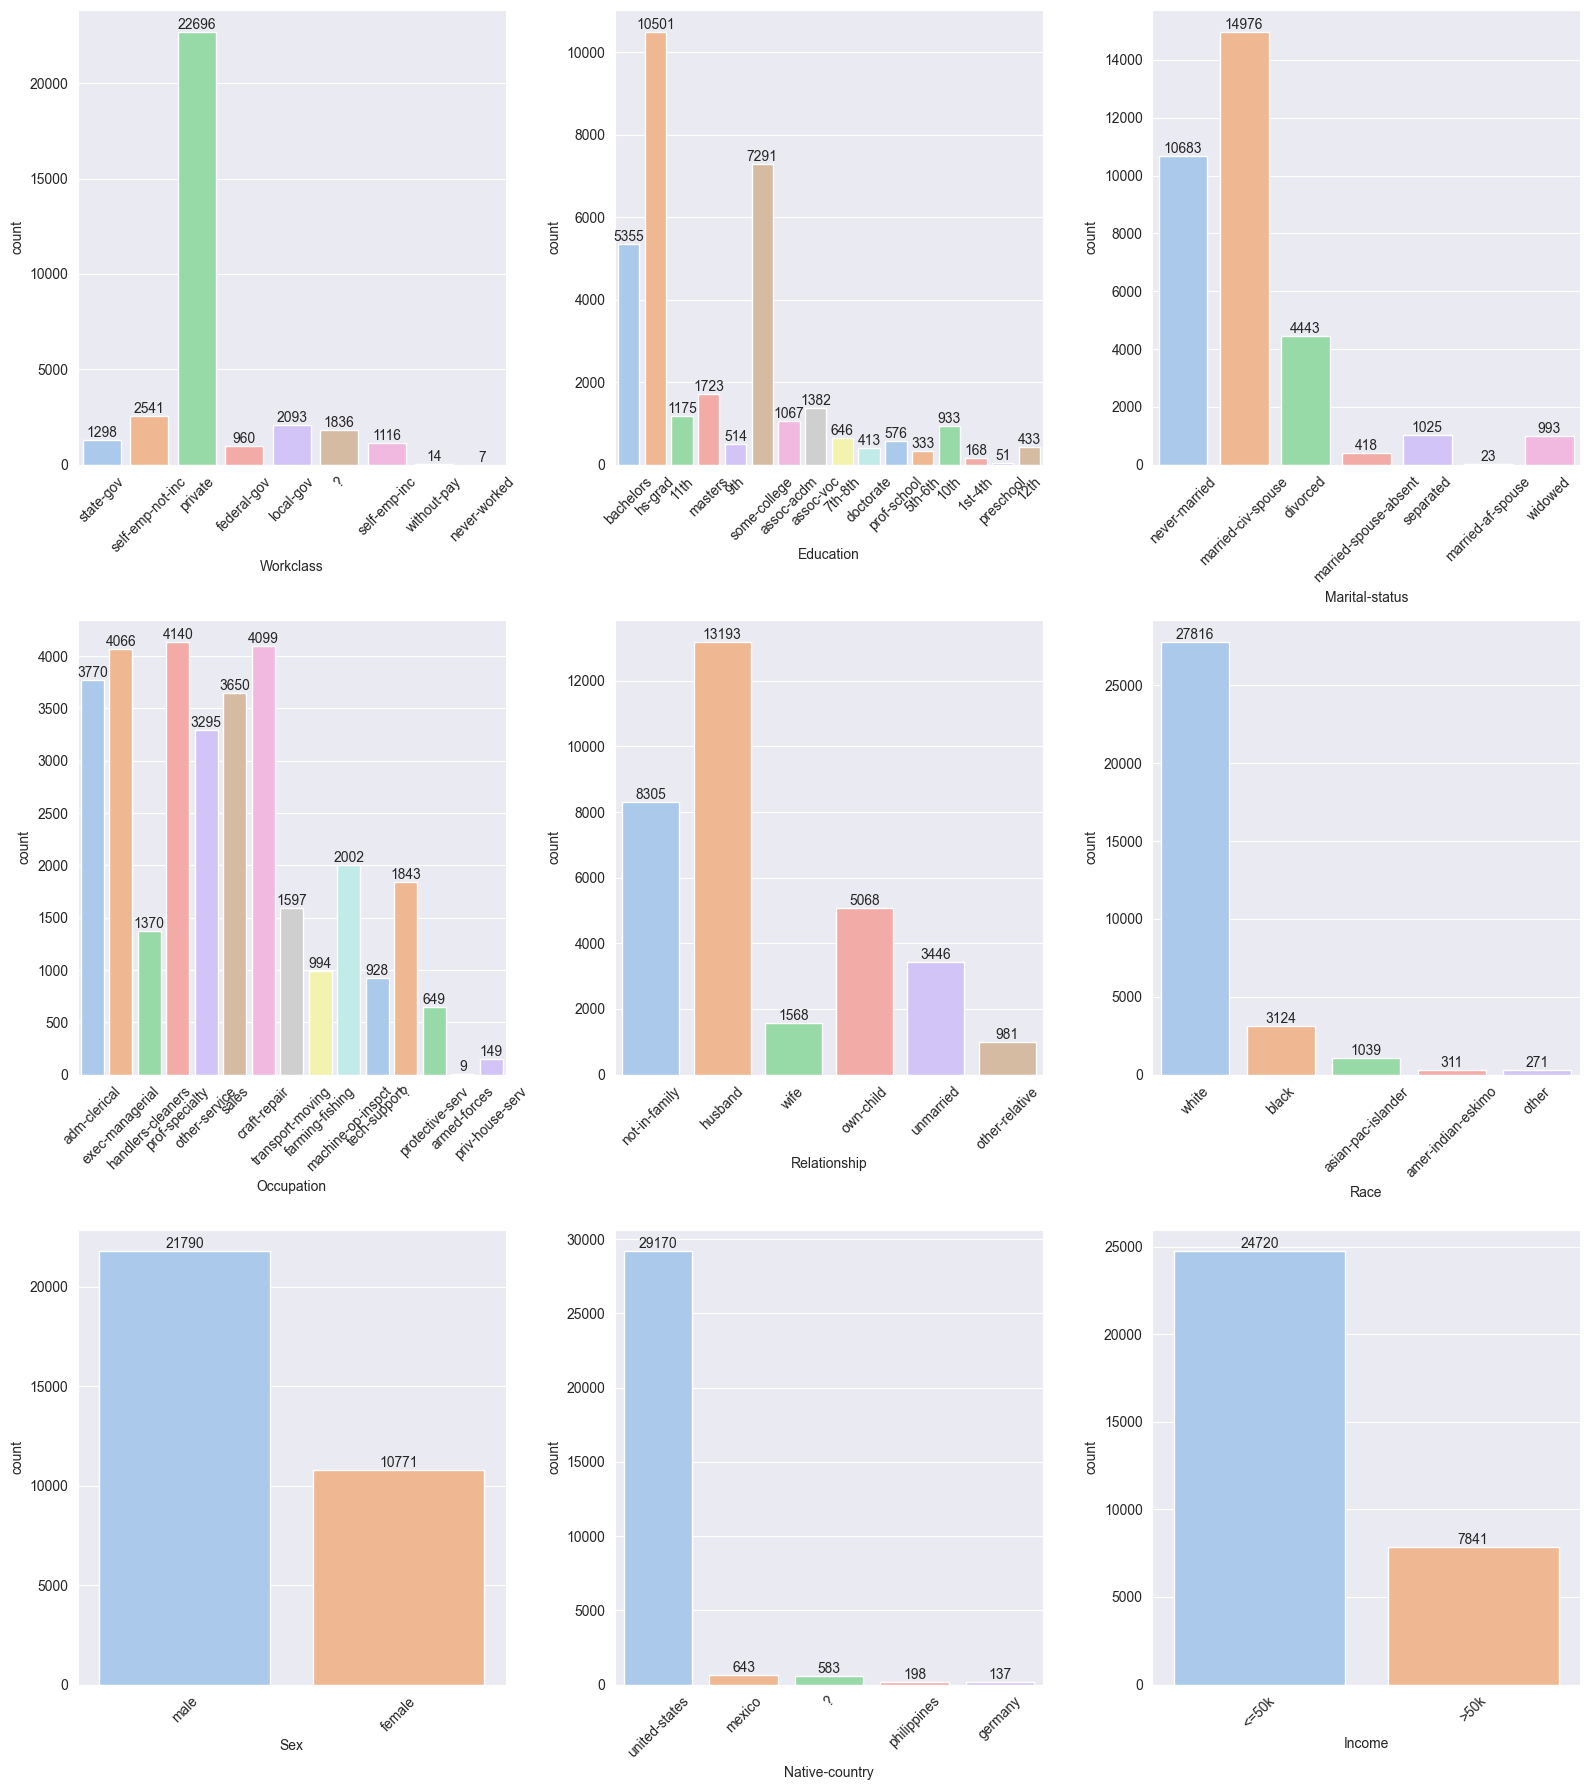

In [12]:
categoric = get_categoric()

col = 3
row = math.ceil((len(categoric) / col))

fig, ax = plt.subplots(row, col, figsize = (16, row * 6))
ax = ax.ravel()

for idx, column in enumerate(categoric):
    if column == "native-country":
        
        top5 = df[column].value_counts().head(5).index

        axis = sns.countplot(
            data= df[df[column].isin(top5)],
            x= column,
            order= top5,
            ax= ax[idx],
            palette= "pastel"
        )
    else:
        axis = sns.countplot(
            data= df,
            x= column,
            ax= ax[idx],
            palette= "pastel"
        )

    for container in axis.containers:
        axis.bar_label(container)

    axis.set_xlabel(f"{column.capitalize()}")
    axis.set_xticks(axis.get_xticks())
    axis.set_xticklabels(axis.get_xticklabels(), rotation = 45)

plt.tight_layout()
plt.show()

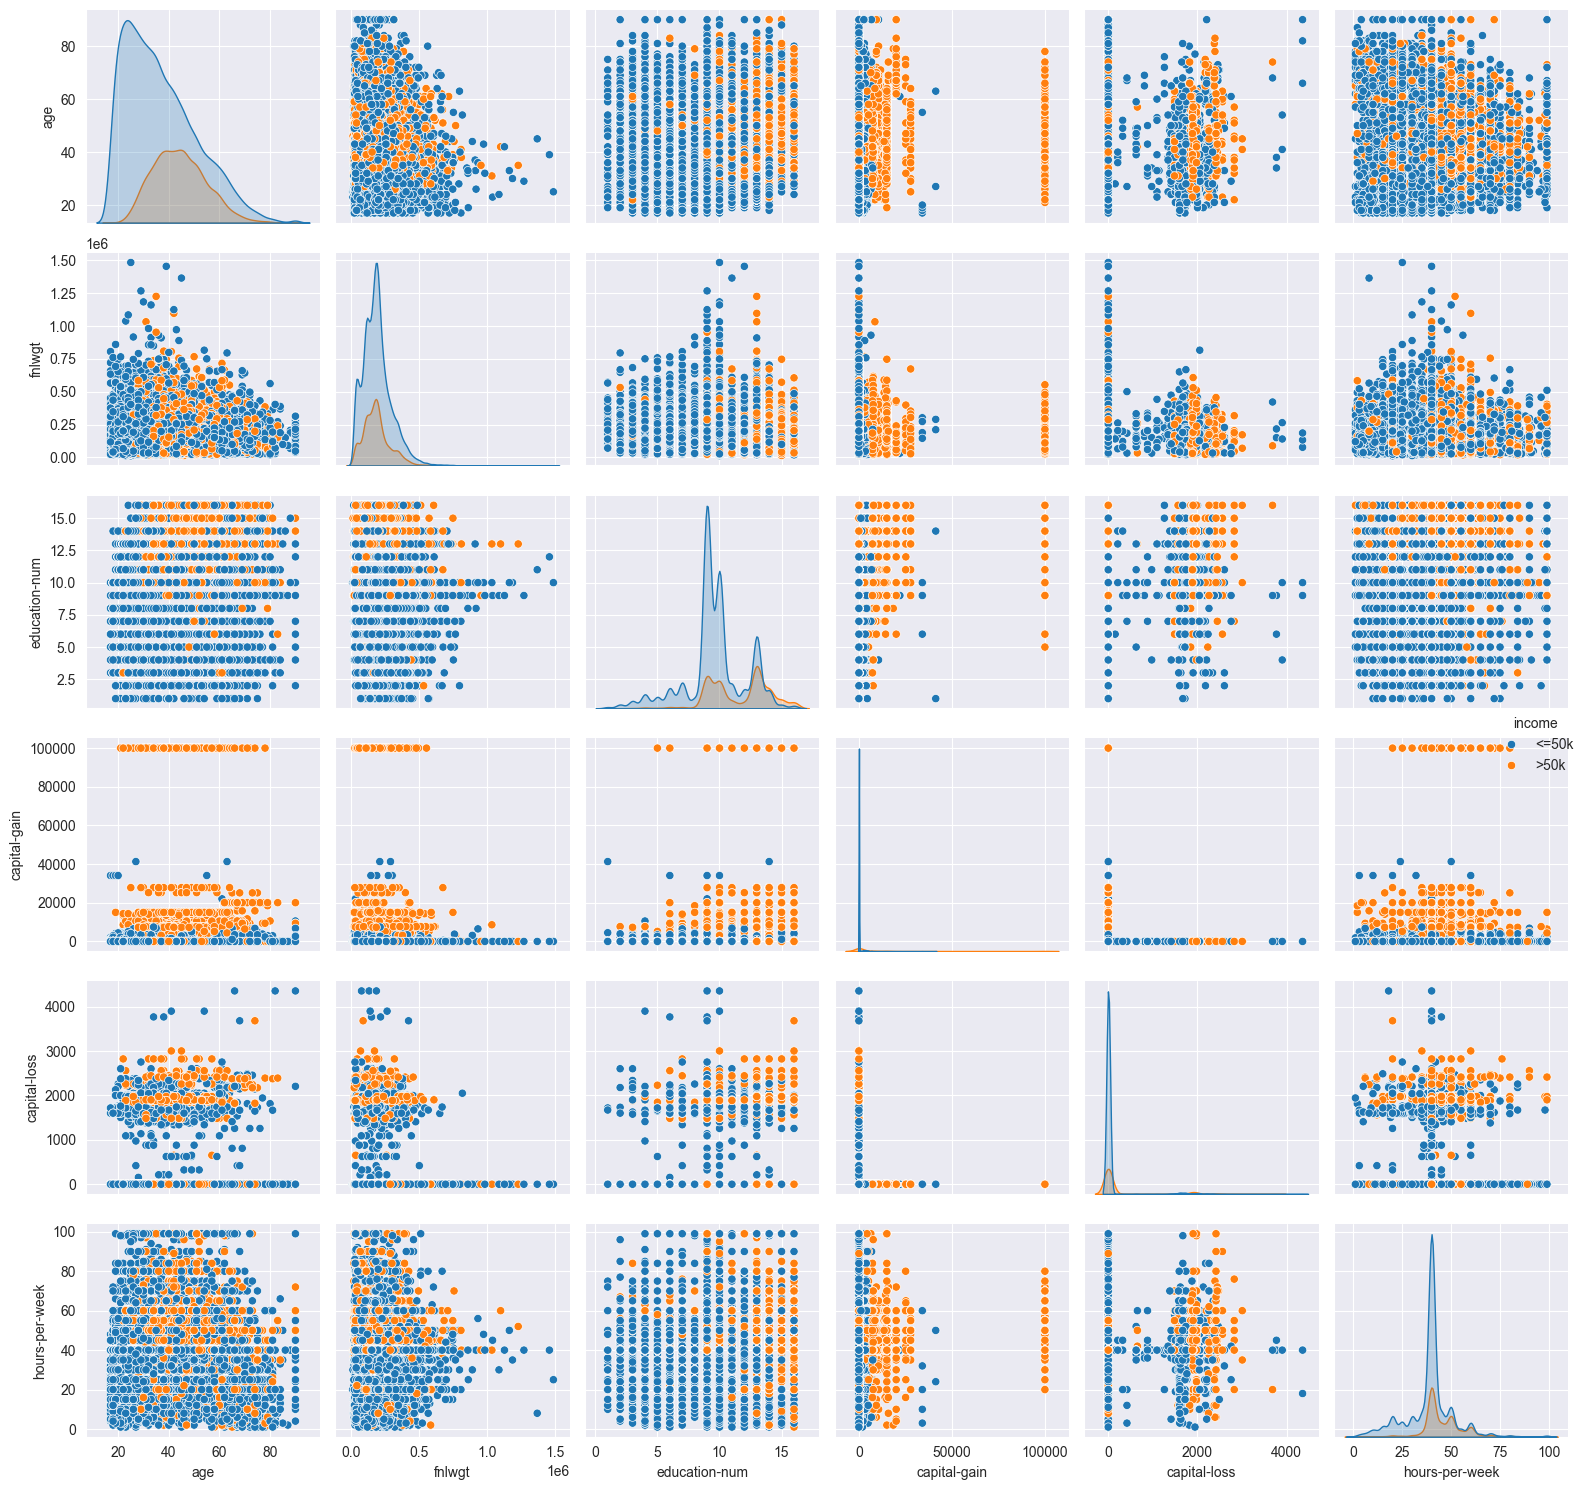

In [13]:
sns.pairplot(df, hue= "income")

plt.tight_layout()
plt.show()

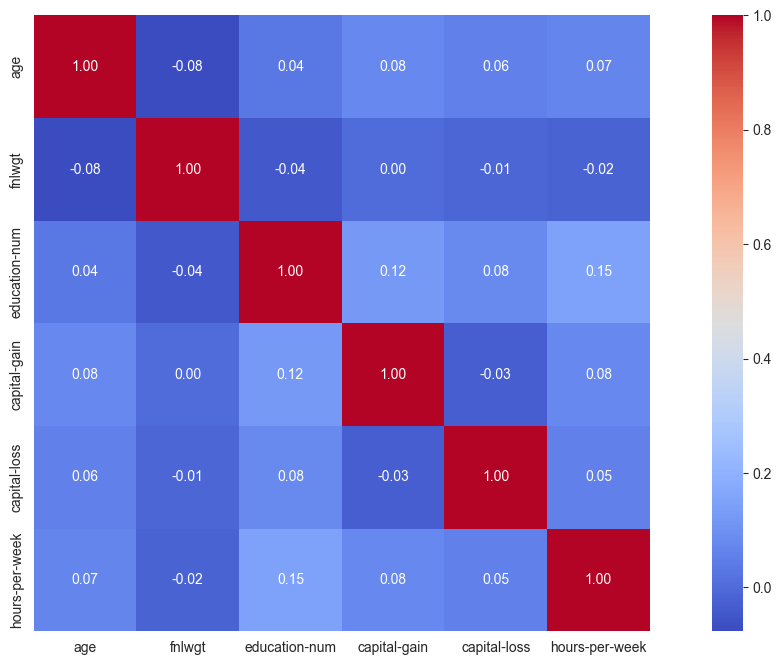

In [14]:
corr = df.corr(numeric_only= True)

sns.heatmap(corr, cmap= "coolwarm", square= True, annot= True, fmt= ".2f")

plt.show()

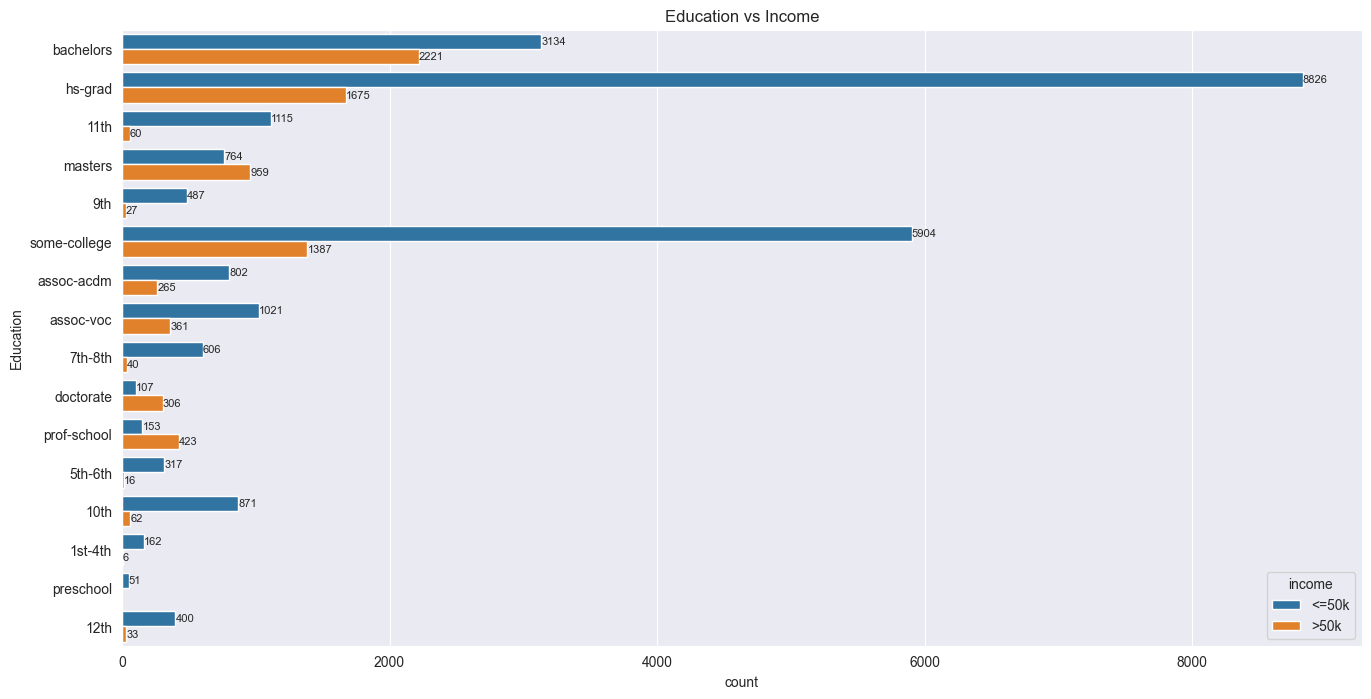

In [15]:
ax = sns.countplot(
    data= df,
    y= "education",
    hue= "income"
)

for container in ax.containers:
    ax.bar_label(container, fontsize = 8)

plt.title("Education vs Income")
plt.ylabel("Education")

plt.show()

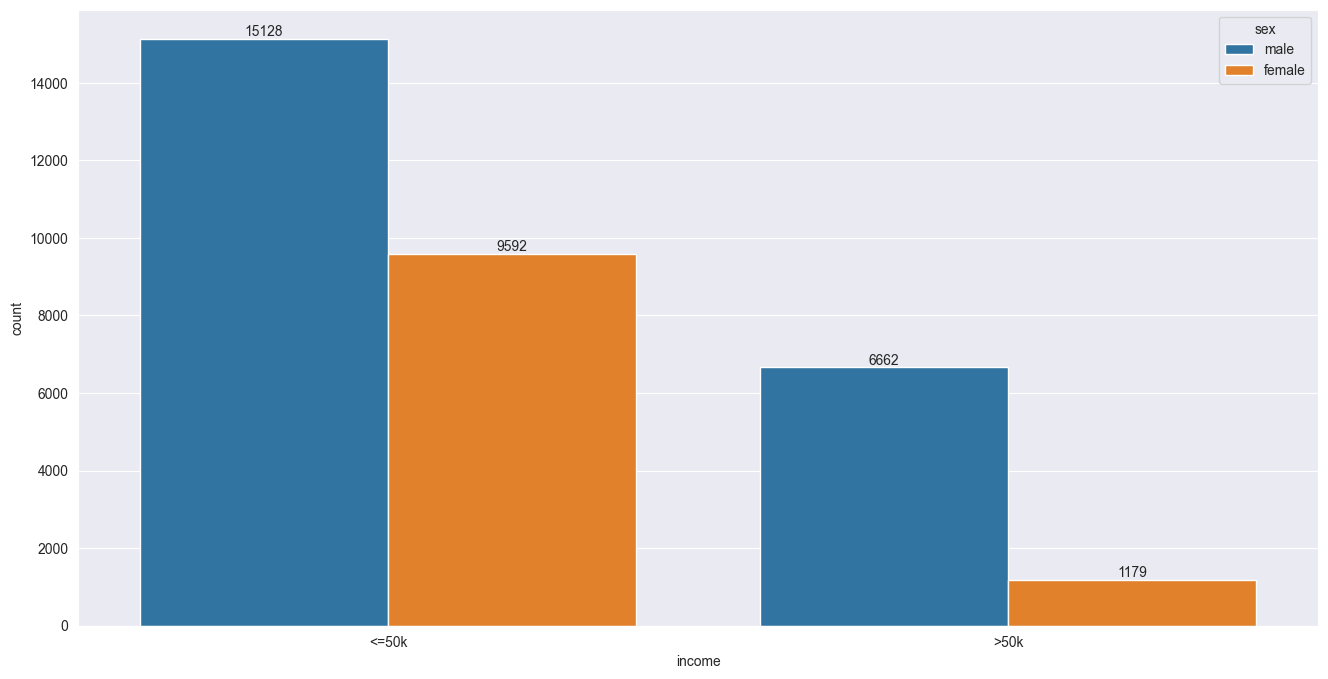

In [16]:
ax = sns.countplot(
    data= df,
    hue= "sex",
    x= "income"
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

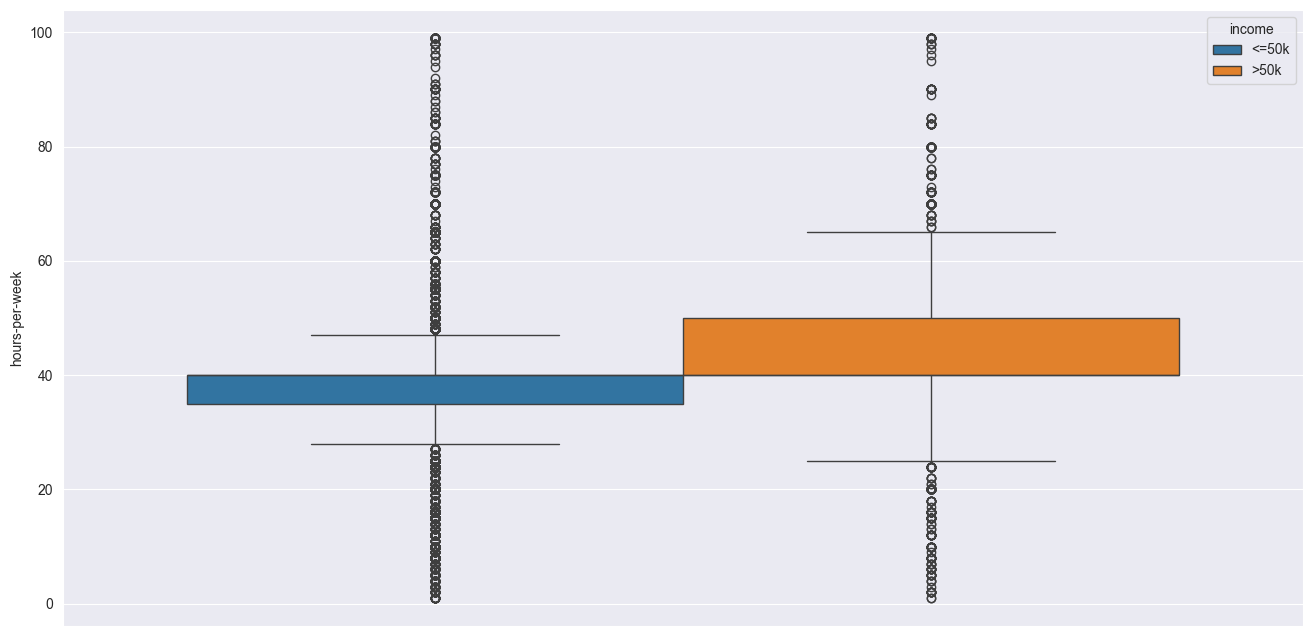

In [17]:
sns.boxplot(
    data= df,
    y= "hours-per-week",
    hue= "income"
)

plt.show()

In [18]:
# Income vs average hours per week by country
result = df.groupby(["native-country",  "income"])["hours-per-week"].mean().unstack()
result.sort_values(by= ">50k").head(10)

income,<=50k,>50k
native-country,,
guatemala,39.360656,36.666667
nicaragua,36.093750,37.500000
china,37.381818,38.900000
poland,38.166667,39.000000
vietnam,37.193548,39.200000
puerto-rico,38.470588,39.416667
cambodia,41.416667,40.000000
laos,40.375000,40.000000
trinadad&tobago,37.058824,40.000000


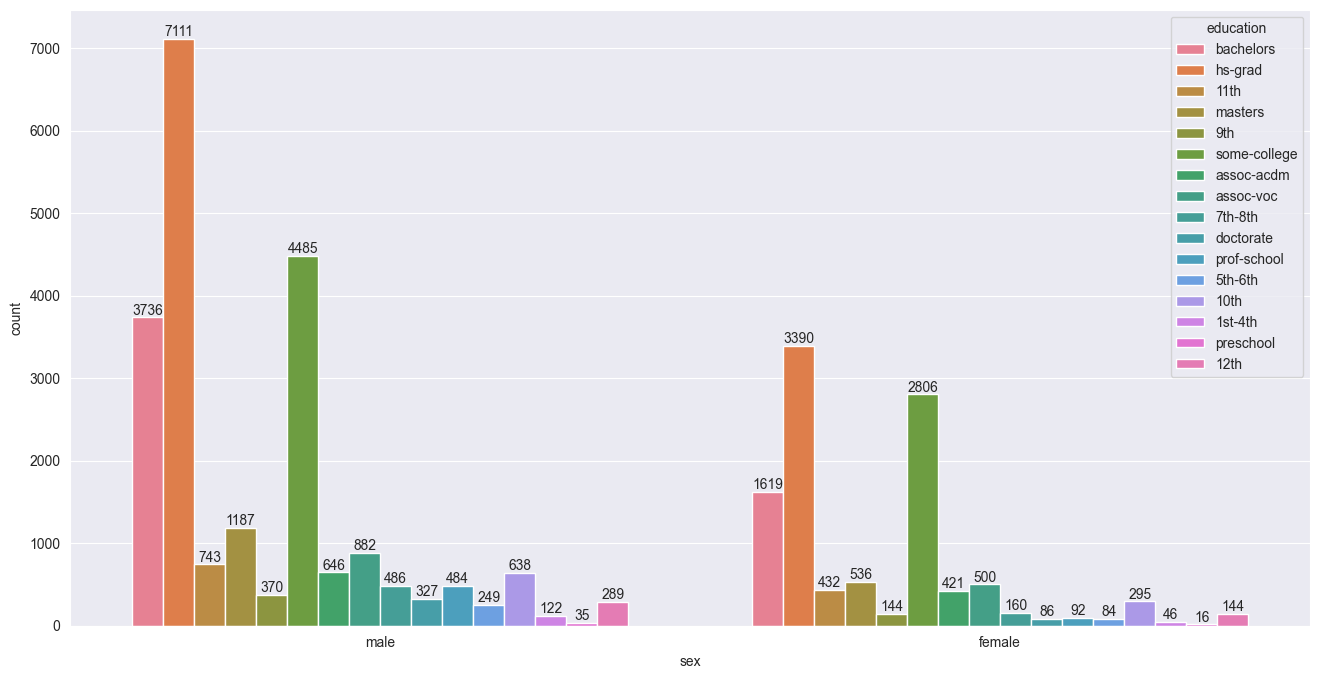

In [19]:
ax = sns.countplot(
    data= df,
    x= "sex",
    hue= "education"
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Encoding

In [20]:
# Replace '?' and ' nan' with Nan
df = df.replace(["?", " nan"], np.nan)

In [21]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,state-gov,77516,bachelors,13,never-married,adm-clerical,not-in-family,white,male,2174,0,40,united-states,<=50k
1,50,self-emp-not-inc,83311,bachelors,13,married-civ-spouse,exec-managerial,husband,white,male,0,0,13,united-states,<=50k
2,38,private,215646,hs-grad,9,divorced,handlers-cleaners,not-in-family,white,male,0,0,40,united-states,<=50k
3,53,private,234721,11th,7,married-civ-spouse,handlers-cleaners,husband,black,male,0,0,40,united-states,<=50k
4,28,private,338409,bachelors,13,married-civ-spouse,prof-specialty,wife,black,female,0,0,40,cuba,<=50k


In [22]:
df.drop(labels= ["fnlwgt", "education"], axis= 1, inplace= True)

In [23]:
df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,state-gov,13,never-married,adm-clerical,not-in-family,white,male,2174,0,40,united-states,<=50k
1,50,self-emp-not-inc,13,married-civ-spouse,exec-managerial,husband,white,male,0,0,13,united-states,<=50k
2,38,private,9,divorced,handlers-cleaners,not-in-family,white,male,0,0,40,united-states,<=50k
3,53,private,7,married-civ-spouse,handlers-cleaners,husband,black,male,0,0,40,united-states,<=50k
4,28,private,13,married-civ-spouse,prof-specialty,wife,black,female,0,0,40,cuba,<=50k


In [24]:
df["sex"] = df["sex"].map({"male" : 0, "female" : 1})

In [25]:
df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,state-gov,13,never-married,adm-clerical,not-in-family,white,0,2174,0,40,united-states,<=50k
1,50,self-emp-not-inc,13,married-civ-spouse,exec-managerial,husband,white,0,0,0,13,united-states,<=50k
2,38,private,9,divorced,handlers-cleaners,not-in-family,white,0,0,0,40,united-states,<=50k
3,53,private,7,married-civ-spouse,handlers-cleaners,husband,black,0,0,0,40,united-states,<=50k
4,28,private,13,married-civ-spouse,prof-specialty,wife,black,1,0,0,40,cuba,<=50k


In [26]:
df.isnull().sum()

age                  0
workclass         1836
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [27]:
X = df.drop("income", axis = 1)
y = df["income"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [29]:
categoric = get_categoric(X_train)

X_train[categoric].isnull().sum()

workclass         1447
marital-status       0
occupation        1454
relationship         0
race                 0
native-country     458
dtype: int64

In [30]:
for i in [X_train, X_test]:
    i["workclass"] = i["workclass"].fillna(X_train["workclass"].mode()[0])
    i["occupation"] = i["occupation"].fillna(X_train["occupation"].mode()[0])
    i["native-country"] = i["native-country"].fillna(X_train["native-country"].mode()[0])

In [31]:
X_train.isnull().sum()

age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

In [32]:
X_test.isnull().sum()

age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

In [33]:
categoric = get_categoric(df)

df[categoric].nunique()

workclass          8
marital-status     7
occupation        14
relationship       6
race               5
native-country    41
income             2
dtype: int64

In [34]:
y_train_binary = y_train.apply(lambda x: 1 if x == ">50k" else 0)

target_means = y_train_binary.groupby(X_train["native-country"]).mean()

target_means

native-country
cambodia                      0.375000
canada                        0.313131
china                         0.210526
columbia                      0.037736
cuba                          0.263158
dominican-republic            0.032258
ecuador                       0.086957
el-salvador                   0.093023
england                       0.342105
france                        0.500000
germany                       0.295238
greece                        0.272727
guatemala                     0.058824
haiti                         0.105263
holand-netherlands            0.000000
honduras                      0.000000
hong                          0.416667
hungary                       0.100000
india                         0.405063
iran                          0.419355
ireland                       0.210526
italy                         0.355932
jamaica                       0.147059
japan                         0.392157
laos                          0.071429
mexico    

In [35]:
X_train["native-country-encoded"] = X_train["native-country"].map(target_means)
X_train["native-country-encoded"] = X_train["native-country-encoded"].fillna(y_train_binary.mean())

X_test['native-country-encoded'] = X_test['native-country'].map(target_means)
X_test['native-country-encoded'] = X_test['native-country-encoded'].fillna(y_train_binary.mean())

In [36]:
X_train.drop("native-country", axis= 1 , inplace= True)
X_test.drop("native-country", axis= 1 , inplace= True)

In [37]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ohe_categories = ['workclass', 'marital-status', 'occupation', 'relationship', 'race']

encoder = ColumnTransformer(
    transformers= [
        ("categoric", OneHotEncoder(handle_unknown= "ignore", sparse_output= False), ohe_categories)
    ],
    remainder= "passthrough"
)

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [38]:
columns = encoder.get_feature_names_out()

In [39]:
X_train_encoded = pd.DataFrame(X_train_encoded, columns= columns, index= X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=columns, index=X_test.index)

In [40]:
X_train_encoded

,categoric__workclass_federal-gov,categoric__workclass_local-gov,categoric__workclass_never-worked,categoric__workclass_private,categoric__workclass_self-emp-inc,categoric__workclass_self-emp-not-inc,categoric__workclass_state-gov,categoric__workclass_without-pay,categoric__marital-status_divorced,categoric__marital-status_married-af-spouse,...,categoric__race_black,categoric__race_other,categoric__race_white,remainder__age,remainder__education-num,remainder__sex,remainder__capital-gain,remainder__capital-loss,remainder__hours-per-week,remainder__native-country-encoded
5514,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,33.0,13.0,1.0,0.0,0.0,50.0,0.246275
19777,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,36.0,11.0,0.0,0.0,1887.0,50.0,0.246275
10781,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,58.0,5.0,0.0,0.0,0.0,40.0,0.246275
32240,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,21.0,11.0,0.0,0.0,0.0,46.0,0.246275
9876,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,27.0,10.0,0.0,0.0,0.0,40.0,0.246275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,47.0,13.0,0.0,0.0,0.0,40.0,0.246275
5390,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,31.0,8.0,1.0,0.0,0.0,21.0,0.246275
860,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,18.0,7.0,1.0,0.0,0.0,20.0,0.246275
15795,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,50.0,9.0,0.0,0.0,0.0,84.0,0.246275


In [41]:
columns = X_train_encoded.columns

In [42]:
# we don't actually need scaling in dt algortihms but let's do it because we will introduce robust scaler

In [43]:
# robust scaler is different than standardscaler and it is designed to handle outliers.

In [44]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train_encoded)
X_test = scaler.transform(X_test_encoded)


In [45]:
X_train = pd.DataFrame(X_train, columns= columns)
X_test = pd.DataFrame(X_test, columns= columns)

In [46]:
X_train

,categoric__workclass_federal-gov,categoric__workclass_local-gov,categoric__workclass_never-worked,categoric__workclass_private,categoric__workclass_self-emp-inc,categoric__workclass_self-emp-not-inc,categoric__workclass_state-gov,categoric__workclass_without-pay,categoric__marital-status_divorced,categoric__marital-status_married-af-spouse,...,categoric__race_black,categoric__race_other,categoric__race_white,remainder__age,remainder__education-num,remainder__sex,remainder__capital-gain,remainder__capital-loss,remainder__hours-per-week,remainder__native-country-encoded
0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.20,1.000000,1.0,0.0,0.0,2.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.05,0.333333,0.0,0.0,1887.0,2.0,0.0
2,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.05,-1.666667,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.80,0.333333,0.0,0.0,0.0,1.2,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,-0.50,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26043,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.50,1.000000,0.0,0.0,0.0,0.0,0.0
26044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,-0.30,-0.666667,1.0,0.0,0.0,-3.8,0.0
26045,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.95,-1.000000,1.0,0.0,0.0,-4.0,0.0
26046,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.65,-0.333333,0.0,0.0,0.0,8.8,0.0


## Training

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rfc = RandomForestClassifier(n_estimators= 10, random_state= 42)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [49]:
predicts = rfc.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [51]:
print(f'Model accuracy : {accuracy_score(y_test, predicts):.2%}')
print("Classification Report ", classification_report(y_test, predicts))
print("Confusion Matrix\n", confusion_matrix(y_test, predicts))


Model accuracy : 84.12%
Classification Report                precision    recall  f1-score   support

       <=50k       0.88      0.92      0.90      4942
        >50k       0.70      0.60      0.65      1571

    accuracy                           0.84      6513
   macro avg       0.79      0.76      0.77      6513
weighted avg       0.84      0.84      0.84      6513

Confusion Matrix
 [[4535  407]
 [ 627  944]]


In [52]:
rfc.feature_importances_

array([5.95038237e-03, 5.65221754e-03, 2.40386807e-05, 1.15142189e-02,
       6.17621990e-03, 8.68706851e-03, 4.46113534e-03, 6.08827325e-05,
       3.53489911e-03, 4.26000867e-04, 1.01159252e-01, 1.01417900e-03,
       1.73978100e-02, 1.25386676e-03, 1.27043233e-03, 4.86510373e-03,
       3.73486510e-06, 5.93366702e-03, 2.00309975e-02, 3.86348056e-03,
       3.52969391e-03, 4.21696232e-03, 5.37325837e-03, 1.65536557e-04,
       1.28671615e-02, 2.82464706e-03, 6.73366306e-03, 4.91148765e-03,
       4.76644983e-03, 5.03549433e-02, 6.72489902e-03, 1.58848721e-03,
       9.34237567e-03, 3.47870865e-03, 1.21384873e-02, 1.35842861e-03,
       3.08700563e-03, 4.86151746e-03, 1.02327424e-03, 6.50868799e-03,
       2.26539363e-01, 1.42611514e-01, 1.14193272e-02, 9.76527105e-02,
       3.39829933e-02, 1.16183897e-01, 2.24749311e-02])

In [53]:
feature_scores = pd.Series(rfc.feature_importances_, index= X_train.columns).sort_values(ascending= False)
feature_scores

remainder__age                                     0.226539
remainder__education-num                           0.142612
remainder__hours-per-week                          0.116184
categoric__marital-status_married-civ-spouse       0.101159
remainder__capital-gain                            0.097653
categoric__relationship_husband                    0.050355
remainder__capital-loss                            0.033983
remainder__native-country-encoded                  0.022475
categoric__occupation_exec-managerial              0.020031
categoric__marital-status_never-married            0.017398
categoric__occupation_prof-specialty               0.012867
categoric__relationship_wife                       0.012138
categoric__workclass_private                       0.011514
remainder__sex                                     0.011419
categoric__relationship_own-child                  0.009342
categoric__workclass_self-emp-not-inc              0.008687
categoric__occupation_sales             

In [54]:
feature_scores.tail(10)

categoric__race_amer-indian-eskimo                 0.001358
categoric__marital-status_widowed                  0.001270
categoric__marital-status_separated                0.001254
categoric__race_other                              0.001023
categoric__marital-status_married-spouse-absent    0.001014
categoric__marital-status_married-af-spouse        0.000426
categoric__occupation_priv-house-serv              0.000166
categoric__workclass_without-pay                   0.000061
categoric__workclass_never-worked                  0.000024
categoric__occupation_armed-forces                 0.000004
dtype: float64

In [55]:
X_train.drop(['categoric__race_amer-indian-eskimo',
       'categoric__marital-status_widowed',
       'categoric__marital-status_separated', 'categoric__race_other',
       'categoric__marital-status_married-spouse-absent',
       'categoric__marital-status_married-af-spouse',
       'categoric__occupation_priv-house-serv',
       'categoric__workclass_without-pay', 'categoric__workclass_never-worked',
       'categoric__occupation_armed-forces'], axis = 1, inplace = True)

In [56]:
X_test.drop(['categoric__race_amer-indian-eskimo',
       'categoric__marital-status_widowed',
       'categoric__marital-status_separated', 'categoric__race_other',
       'categoric__marital-status_married-spouse-absent',
       'categoric__marital-status_married-af-spouse',
       'categoric__occupation_priv-house-serv',
       'categoric__workclass_without-pay', 'categoric__workclass_never-worked',
       'categoric__occupation_armed-forces'], axis = 1, inplace = True)

In [57]:
rfc = RandomForestClassifier(n_estimators= 10, random_state= 42)
rfc.fit(X_train, y_train)

predicts = rfc.predict(X_test)

print(f'Model accuracy : {accuracy_score(y_test, predicts):.2%}')
print("Classification Report\n", classification_report(y_test, predicts))
print("Confusion Matrix\n", confusion_matrix(y_test, predicts))


Model accuracy : 83.83%
Classification Report
               precision    recall  f1-score   support

       <=50k       0.87      0.92      0.90      4942
        >50k       0.70      0.58      0.64      1571

    accuracy                           0.84      6513
   macro avg       0.79      0.75      0.77      6513
weighted avg       0.83      0.84      0.83      6513

Confusion Matrix
 [[4542  400]
 [ 653  918]]


In [58]:
#Hyperparameter Tuning

In [59]:
from sklearn.model_selection import RandomizedSearchCV

In [60]:
rfc = RandomForestClassifier()

In [61]:
n_estimators = [1, 10, 100, 1000]
max_depth = [10, 20, 40, 60, None]
min_samples_split = [1, 5, 10]
max_features = ["sqrt", "log2"]
n_jobs = [-1]

In [62]:
params = dict(
    n_estimators = n_estimators,
    max_depth = max_depth,
    min_samples_split = min_samples_split,
    max_features = max_features,
    n_jobs = n_jobs
)

In [63]:
random = RandomizedSearchCV(
    estimator= rfc,
    param_distributions= params,
    cv= 5,
    n_jobs= -1,
    random_state= 42
)

In [64]:
random.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 40, 60, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_split': [1, 5, 10],
                                        'n_estimators': [1, 10, 100, 1000],
                                        'n_jobs': [-1]},
                   random_state=42)

In [65]:
random.best_estimator_

RandomForestClassifier(max_depth=20, max_features='log2', min_samples_split=10,
                       n_estimators=1000, n_jobs=-1)

In [66]:
random.best_params_

{'n_jobs': -1,
 'n_estimators': 1000,
 'min_samples_split': 10,
 'max_features': 'log2',
 'max_depth': 20}

In [67]:
predicts = random.predict(X_test)

print(f'Model accuracy : {accuracy_score(y_test, predicts):.2%}')
print("Classification Report\n", classification_report(y_test, predicts))
print("Confusion Matrix\n", confusion_matrix(y_test, predicts))


Model accuracy : 86.86%
Classification Report
               precision    recall  f1-score   support

       <=50k       0.89      0.95      0.92      4942
        >50k       0.79      0.62      0.69      1571

    accuracy                           0.87      6513
   macro avg       0.84      0.78      0.81      6513
weighted avg       0.86      0.87      0.86      6513

Confusion Matrix
 [[4684  258]
 [ 598  973]]
